In [1]:
# Path to the aggregated BIDS participants table for this dataset
from pathlib import Path

DATASET_PATH = Path("/home/UWO/oolejar/lightsheet/mouse_app_lecanemab_ki3_aggregated/bids/participants.tsv")

In [2]:
# participants.tsv is tab-separated, per BIDS convention
import pandas as pd

df = pd.read_csv(DATASET_PATH, sep="\t")

df.head()

,participant_id,batch_id,bag_id,participant_label,sex,treatment,age,genotype,antibodies,has_mri,notes,QC_notes
0,sub-AS134F3,1,a,AS134F3,F,PBS,14.0,App-NLGF,"647 IBA1, Se tau Gp- 561 A-beta red X Rb, 488 ...",Y,NaN,Bottom of brain is very blurry due to mounting...
1,sub-AS135M5,1,b,AS135M5,M,PBS,14.0,App-NLGF,"647 IBA1, Se tau Gp- 561 A-beta red X Rb, 488 ...",Y,NaN,NaN
2,sub-AS135M8,1,c,AS135M8,M,PBS,14.0,App-NLGF,"647 IBA1, Se tau Gp- 561 A-beta red X Rb, 488 ...",Y,NaN,NaN
3,sub-AS134F1,1,d,AS134F1,F,Lecanemab,14.0,App-NLGF,"647 IBA1, Se tau Gp- 561 A-beta red X Rb, 488 ...",Y,NaN,NaN
4,sub-AS135M6,1,e,AS135M6,M,Lecanemab,14.0,App-NLGF,"647 IBA1, Se tau Gp- 561 A-beta red X Rb, 488 ...",Y,NaN,NaN


In [3]:
df.tail()

,participant_id,batch_id,bag_id,participant_label,sex,treatment,age,genotype,antibodies,has_mri,notes,QC_notes
31,sub-AS17F5,4,d,AS17F5,F,Lecanemab,14.0,App-NLGF,"647 IBA1, Se tau Gp- 561 A-beta red X Rb, 488 ...",Y,NaN,Some damage to left olfactory bulb
32,sub-AS17F6,4,e,AS17F6,F,Lecanemab,14.0,App-NLGF,"647 IBA1, Se tau Gp- 561 A-beta red X Rb, 488 ...",Y,NaN,NaN
33,sub-AS16M2,4,f,AS16M2,M,Lecanemab,14.0,App-NLGF,"647 IBA1, Se tau Gp- 561 A-beta red X Rb, 488 ...",Y,NaN,NaN
34,sub-AS16M3,4,g,AS16M3,M,Lecanemab,14.0,App-NLGF,"647 IBA1, Se tau Gp- 561 A-beta red X Rb, 488 ...",Y,NaN,Bubble in left lateral ventricle.
35,sub-AS16M4,4,h,AS16M4,M,Lecanemab,14.0,App-NLGF,"647 IBA1, Se tau Gp- 561 A-beta red X Rb, 488 ...",Y,NaN,Right posterior cortical tissue damage.


## SPIMquant derivatives

Output of the [SPIMquant](https://github.com/khanlab/SPIMquant) pipeline: one BIDS-derivatives
tree with a subdirectory per data type (`micr`, `parc`, `featuremap`, `seg`, `tabular`, `qc`, `xfm`).
We explore each type using a single subject before scaling up to all subjects.

In [4]:
# Root of the SPIMquant derivatives dataset, and one subject/session to explore first
DERIVATIVES_PATH = Path(
    "/home/UWO/oolejar/lightsheet/mouse_app_lecanemab_ki3_aggregated/derivatives/spimquant-v0.9.0_lantern"
)
SUBJECT_DIR = DERIVATIVES_PATH / "sub-AS10M6" / "ses-exvivo"

### tabular/

Plain `.tsv`/`.parquet` tables, each with a `.json` sidecar giving a `LongName`/`Description`/`Units`
per column (standard BIDS practice). `mergedsegstats` is one row per atlas region, with columns
per stain (e.g. `Abeta+count`, `Abeta+density`) — this is the ROI-level summary table most useful
for population-level analysis later on.

In [5]:
import json

mergedsegstats_tsv = (
    SUBJECT_DIR
    / "tabular"
    / "sub-AS10M6_ses-exvivo_sample-brain_acq-4x_seg-mid_from-ABAv3_desc-lantern_mergedsegstats.tsv"
)
mergedsegstats_json = mergedsegstats_tsv.with_suffix(".json")

# Column meanings live in the JSON sidecar, not in the table itself
with open(mergedsegstats_json) as f:
    column_descriptions = json.load(f)
print(json.dumps(column_descriptions, indent=2))

mergedsegstats = pd.read_csv(mergedsegstats_tsv, sep="\t")
print(mergedsegstats.shape)
mergedsegstats.head()

{
  "index": {
    "LongName": "Atlas region index",
    "Description": "Integer index of the brain atlas region (label value in the parcellation image)."
  },
  "name": {
    "LongName": "Atlas region name",
    "Description": "Human-readable name of the brain atlas region."
  },
  "Abeta+nvoxels": {
    "LongName": "Number of voxels (Abeta)",
    "Description": "Total number of foreground voxels belonging to the segmented object or region. Stain/channel: Abeta.",
    "Units": "voxels"
  },
  "Abeta+stain": {
    "LongName": "Staining channel (Abeta)",
    "Description": "Name of the immunofluorescence or histochemical stain/channel associated with this object. Stain/channel: Abeta."
  },
  "Abeta+count": {
    "LongName": "Object count (Abeta)",
    "Description": "Number of segmented objects (e.g. plaques, cells) detected within the region. Stain/channel: Abeta.",
    "Units": "objects"
  },
  "Abeta+fieldfrac": {
    "LongName": "Field fraction (Abeta)",
    "Description": "Fractio

,index,name,Abeta+nvoxels,Abeta+stain,Abeta+count,Abeta+fieldfrac,Abeta+volume,Abeta+density
0,0,Unknown_Label_0,646832056.0,Abeta,211804.0,0.000000,NaN,NaN
1,1,L_Frontal pole\t cerebral cortex,6021088.0,Abeta,3571.0,5.735111,0.521257,6850.753284
2,2,R_Frontal pole\t cerebral cortex,6577048.0,Abeta,3677.0,6.363937,0.518590,7090.375952
3,3,L_Somatomotor areas,146783504.0,Abeta,62934.0,5.500059,13.004941,4839.237499
4,4,R_Somatomotor areas,128887216.0,Abeta,55498.0,5.006467,13.134065,4225.500566


### qc/

Plain `.png` images (intensity histograms, ROI montages, segmentation slice overlays) — viewable
directly, no special tooling needed.

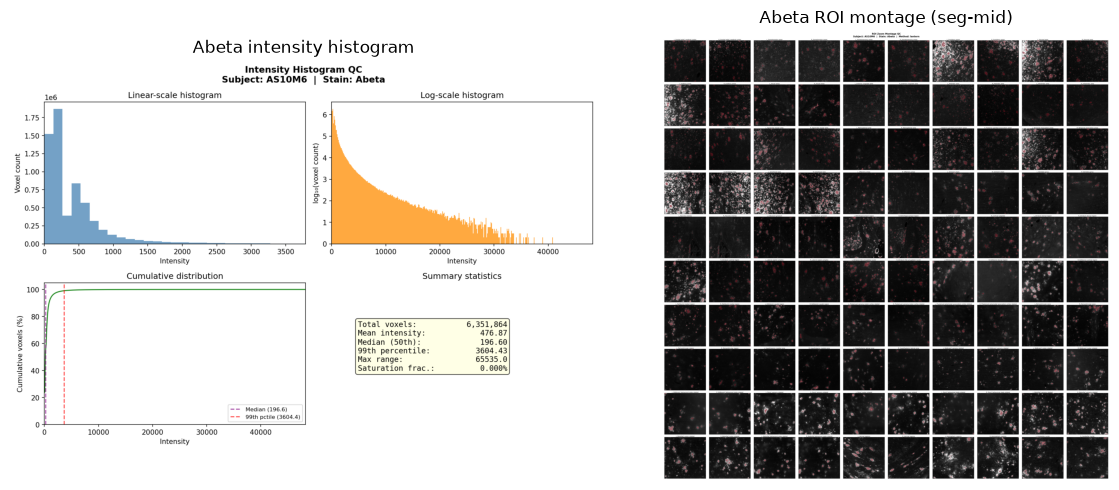

In [6]:
import matplotlib.pyplot as plt
from PIL import Image

qc_dir = SUBJECT_DIR / "qc"
histogram_png = qc_dir / "sub-AS10M6_ses-exvivo_sample-brain_acq-4x_stain-Abeta_histogram.png"
roimontage_png = (
    qc_dir
    / "sub-AS10M6_ses-exvivo_sample-brain_acq-4x_stain-Abeta_seg-mid_from-ABAv3_desc-lantern_roimontage.png"
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(Image.open(histogram_png))
axes[0].set_title("Abeta intensity histogram")
axes[1].imshow(Image.open(roimontage_png))
axes[1].set_title("Abeta ROI montage (seg-mid)")
for ax in axes:
    ax.axis("off")
plt.tight_layout()

### xfm/

Registration transform fields (`.nii.gz`, subject↔atlas warps — loadable with `nibabel` like any
other volume) plus a `_regqc.html` report: a self-contained registration quality-control page,
best viewed in a browser rather than inline in the notebook.

In [7]:
regqc_html = (
    SUBJECT_DIR
    / "xfm"
    / "sub-AS10M6_ses-exvivo_sample-brain_acq-4x_stain-Iba1_from-SPIM_to-ABAv3_regqc.html"
)
print(f"Open in a browser to inspect registration quality:\n{regqc_html}")

Open in a browser to inspect registration quality:
/home/UWO/oolejar/lightsheet/mouse_app_lecanemab_ki3_aggregated/derivatives/spimquant-v0.9.0_lantern/sub-AS10M6/ses-exvivo/xfm/sub-AS10M6_ses-exvivo_sample-brain_acq-4x_stain-Iba1_from-SPIM_to-ABAv3_regqc.html


### micr/

Microscopy volumes (`.nii.gz`) per stain (`Abeta`, `Iba1`) at a given pyramid resolution
(`level-N`), plus brain masks and N4 bias-field-corrected versions. Loaded with `nibabel`.

shape: (222, 311, 92) dtype: uint16
affine (voxel -> mm):
 [[ 0.052     0.        0.        0.      ]
 [ 0.       -0.052     0.        0.      ]
 [ 0.        0.       -0.070432  0.      ]
 [ 0.        0.        0.        1.      ]]


(np.float64(-0.5), np.float64(221.5), np.float64(-0.5), np.float64(310.5))

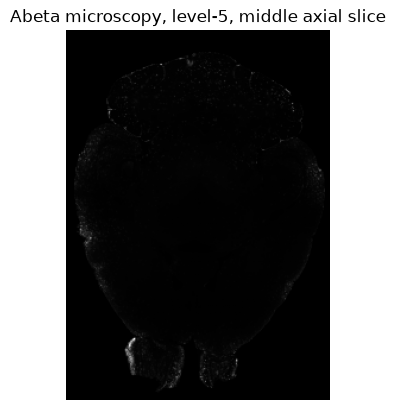

In [8]:
import nibabel as nib

micr_nii = (
    SUBJECT_DIR
    / "micr"
    / "sub-AS10M6_ses-exvivo_sample-brain_acq-4x_stain-Abeta_level-5_SPIM.nii.gz"
)
micr_img = nib.load(micr_nii)
print("shape:", micr_img.shape, "dtype:", micr_img.get_data_dtype())
print("affine (voxel -> mm):\n", micr_img.affine)

micr_data = micr_img.get_fdata()
middle_slice = micr_data[:, :, micr_data.shape[2] // 2]
plt.imshow(middle_slice.T, cmap="gray", origin="lower")
plt.title("Abeta microscopy, level-5, middle axial slice")
plt.axis("off")

### parc/

Discrete atlas parcellation volumes (`dseg.nii.gz`) registered to the subject, at several
granularities (`seg-all/coarse/mid/fine`). Each integer voxel value is a region label; the
label→name mapping lives in the dataset-level `tpl-ABAv3/*_dseg.tsv` lookup table, not in the
volume itself.

100 distinct non-background labels present
   index                              name abbreviation
0      1  L_Frontal pole\t cerebral cortex        L_FRP
1      2  R_Frontal pole\t cerebral cortex        R_FRP
2      3               L_Somatomotor areas         L_MO
3      4               R_Somatomotor areas         R_MO
4      5             L_Somatosensory areas         L_SS


(np.float64(-0.5), np.float64(221.5), np.float64(-0.5), np.float64(310.5))

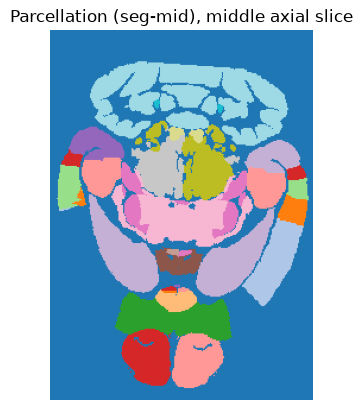

In [9]:
parc_nii = (
    SUBJECT_DIR
    / "parc"
    / "sub-AS10M6_ses-exvivo_sample-brain_acq-4x_seg-mid_from-ABAv3_level-5_dseg.nii.gz"
)
label_lookup_tsv = DERIVATIVES_PATH / "tpl-ABAv3" / "tpl-ABAv3_seg-mid_dseg.tsv"

parc_data = nib.load(parc_nii).get_fdata()
label_lookup = pd.read_csv(label_lookup_tsv, sep="\t")

# Which region labels are actually present in this subject's volume
present_labels = sorted(int(v) for v in pd.unique(parc_data.ravel()) if v != 0)
print(f"{len(present_labels)} distinct non-background labels present")
print(label_lookup[label_lookup["index"].isin(present_labels[:5])])

middle_slice = parc_data[:, :, parc_data.shape[2] // 2]
plt.imshow(middle_slice.T, cmap="tab20", origin="lower")
plt.title("Parcellation (seg-mid), middle axial slice")
plt.axis("off")

### featuremap/

Per-voxel statistic volumes (`.nii.gz`) — the same metrics as `mergedsegstats.tsv`
(`count`/`density`/`volume`/`fieldfrac`/`nvoxels`), but spread spatially over each region rather
than collapsed to one row per region. Note these are in **atlas space** (`space-ABAv3`), unlike
the `parc/` volume above which was warped into subject space (`from-ABAv3`) — so the region-label
volume needed to interpret a featuremap is the template's own `tpl-ABAv3/*_dseg.nii.gz`, not the
per-subject one. As a sanity check, every voxel within a given region should carry that region's
value from the table.

region 1: featuremap voxel value = 6850.75341796875, table value = 6850.75328405321


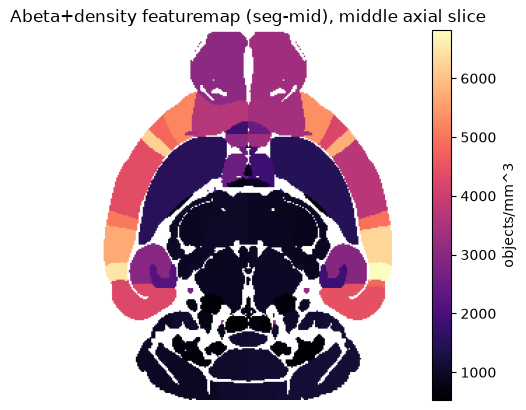

In [10]:
featuremap_nii = (
    SUBJECT_DIR
    / "featuremap"
    / "sub-AS10M6_ses-exvivo_sample-brain_acq-4x_space-ABAv3_seg-mid_desc-lantern_Abeta+density.nii.gz"
)
featuremap_data = nib.load(featuremap_nii).get_fdata()

middle_slice = featuremap_data[:, :, featuremap_data.shape[2] // 2]
plt.imshow(middle_slice.T, cmap="magma", origin="lower")
plt.title("Abeta+density featuremap (seg-mid), middle axial slice")
plt.colorbar(label="objects/mm^3")
plt.axis("off")

# Cross-check against mergedsegstats.tsv: must use the ATLAS-space label volume here,
# since the featuremap is in atlas space while parc_data above is in subject space
tpl_dseg_nii = DERIVATIVES_PATH / "tpl-ABAv3" / "tpl-ABAv3_seg-mid_dseg.nii.gz"
tpl_dseg_data = nib.load(tpl_dseg_nii).get_fdata()

region_label = present_labels[0]
map_value = featuremap_data[tpl_dseg_data == region_label][0]
table_value = mergedsegstats.loc[mergedsegstats["index"] == region_label, "Abeta+density"].item()
print(f"region {region_label}: featuremap voxel value = {map_value}, table value = {table_value}")

### seg/

Raw per-object segmentation outputs. The `.ozx` files aren't a proprietary format — inspecting the
raw bytes shows they're a zipped [OME-Zarr](https://ngff.openmicroscopy.org/) store (`zarr.json`
plus multiscale arrays `s0`...`s7`), just packaged as a single BIDS-style file. `s0` is full
resolution — one full-res mask here is ~1.3GB — so we open a coarse level (`s6`) first rather than
touching `s0`.

resolution levels available: ['s0', 's1', 's2', 's3', 's4', 's5', 's6', 's7']
s6 shape: (1, 46, 155, 111) dtype: uint8


(np.float64(-0.5), np.float64(110.5), np.float64(-0.5), np.float64(154.5))

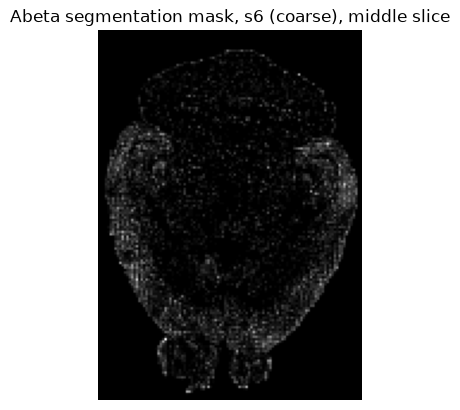

In [11]:
import zarr

seg_ozx = (
    SUBJECT_DIR
    / "seg"
    / "sub-AS10M6_ses-exvivo_sample-brain_acq-4x_stain-Abeta_level-0_desc-lantern_mask.ozx"
)

# The .ozx is a zip file wrapping a zarr store; open it read-only without unzipping to disk
store = zarr.storage.ZipStore(seg_ozx, mode="r", read_only=True)
seg_group = zarr.open_group(store=store, mode="r")

print("resolution levels available:", sorted(seg_group.array_keys()))
coarse_level = seg_group["s6"]
print("s6 shape:", coarse_level.shape, "dtype:", coarse_level.dtype)

# [0] drops the leading channel axis that OME-Zarr volumes carry
coarse_data = coarse_level[0]
middle_slice = coarse_data[coarse_data.shape[0] // 2, :, :]
plt.imshow(middle_slice, cmap="gray", origin="lower")
plt.title("Abeta segmentation mask, s6 (coarse), middle slice")
plt.axis("off")

### Summary: what's in each directory, and how to read it

| Directory | Contents | Tool | Space |
|---|---|---|---|
| `tabular/` | ROI-level (`mergedsegstats`) and object-level (`regionprops*`) stats tables, `.tsv`/`.parquet` + JSON sidecars | `pandas` | n/a |
| `qc/` | Histograms, ROI montages, segmentation overlays, `.png` | `PIL`/`matplotlib` | n/a |
| `xfm/` | Subject↔atlas transform fields, `.nii.gz`; registration QC report, `.html` | `nibabel`; browser | both |
| `micr/` | Raw/processed microscopy volumes per stain, `.nii.gz` | `nibabel` | subject |
| `parc/` | Discrete atlas parcellation labels, `.nii.gz`; label names in `tpl-ABAv3/*_dseg.tsv` | `nibabel` + `pandas` | subject |
| `featuremap/` | Per-voxel versions of the `mergedsegstats` metrics, `.nii.gz` | `nibabel` | **atlas** |
| `seg/` | Raw segmentation masks/probabilities, `.ozx` (zipped OME-Zarr, multiscale `s0`-`s7`) | `zarr` | subject |
| `tpl-ABAv3/` (dataset-level) | Atlas template, brain mask, label volumes + lookup tables | `nibabel` + `pandas` | atlas |

No across-subject aggregation exists yet in this derivatives tree — building that (joining
`mergedsegstats` across all `sub-*` with `participants.tsv` treatment/genotype columns) is the
natural next step once this per-subject structure is confirmed to hold across the other 35
subjects.